# Tool comparison walkthrough: GeoLift vs Google Matched Markets vs CausalImpact

This notebook is a pedagogical companion to the full Monte Carlo study. Instead of
1,000 iterations per scenario, it draws **one sample panel per scenario** and runs
each tool once, so you can see exactly what each method sees and how it responds.

CausalPy is excluded here (see the main study for it). All three tools below are run
at 95% confidence, matching `config/tools.yaml`.

## The four scenarios

| Scenario | Name | Stress test | What to watch for |
|---|---|---|---|
| A1 | Textbook | Clean data, well-behaved donor pool (baseline) | Do all three tools roughly agree? |
| A2 | Outlier (5x) | Treated geo inflated 5x — convex hull violation | Synthetic-control-style donor weighting (GeoLift) can struggle to match a geo outside the donor pool's range |
| A3 | Small donor pool | 10 total geos (1 treated + 9 controls) | Less donor flexibility — does CI width blow up? |
| A4 | Short pre-treatment | 30 pre-treatment days instead of 90 | Less history to calibrate on — does BSTS (CausalImpact) or conformal inference (GeoLift) degrade? |

Each scenario below is generated with a 7.5% true lift on the treated geo, so we can
compare each tool's estimate and CI against a known, exact ground truth.


## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config" / "tools.yaml").exists():
    # allow running from notebooks/ or repo root
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "config" / "tools.yaml").exists(), "Run this notebook from the repo root or notebooks/"
sys.path.insert(0, str(REPO_ROOT))

# run_geolift_subprocess / run_causalimpact_subprocess invoke Rscript with paths
# relative to the repo root (e.g. "src/R/run_geolift.R") — chdir so those
# resolve correctly no matter where Jupyter's cwd started (e.g. notebooks/).
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from src.python.panel_dgp import SCENARIOS, generate_scenario_panel
from src.python.data_converters import to_geolift_format, to_google_mm_format
from src.python.compute_att import compute_true_att, check_coverage
from src.python.run_google_mm import run_google_mm
from src.python.run_tools import run_geolift_subprocess, run_causalimpact_subprocess

with open(REPO_ROOT / "config" / "tools.yaml") as f:
    TOOLS_CFG = yaml.safe_load(f)

GL_ALPHA = TOOLS_CFG["geolift"]["alpha"]
MM_CONFIG = TOOLS_CFG["google_mm"]
CI_CONFIG = TOOLS_CFG["causalimpact"]

EFFECT_PCT = 0.075
SEED = 1

TOOL_COLORS = {"geolift": "#E87461", "google_mm": "#2f465b", "causalimpact": "#4c8c6b"}


## 1. Generate one sample panel per scenario

`generate_scenario_panel` is a Python port of the DGP in `src/R/generate_panels.R`
(shared trend, weekly seasonality, AR(1) noise, log-normal geo baselines). It does not
need to bit-match R's RNG — only to reproduce the same statistical structure — since
this notebook is for exploration, not for reproducing the committed golden results.


In [22]:
panels = {}
for scenario_id in SCENARIOS:
    df, meta = generate_scenario_panel(scenario_id, effect_pct=EFFECT_PCT, seed=SEED)
    panels[scenario_id] = (df, meta)
    print(f"{scenario_id}: {df['geo'].nunique()} geos, {df['date'].max()} days, "
          f"treated={meta['treated_units']}, treatment_start={meta['treatment_start']}")


frames = []
for _scenario_id, (df, meta) in panels.items():
    out = df.drop(columns=["treated"]).copy()
    out["scenario"] = meta["scenario"]
    out["true_effect_pct"] = meta["effect_pct"]
    out["treated_unit"] = df["geo"].isin(meta["treated_units"]).astype(int)
    out["treatment_period"] = (
        (df["date"] >= meta["treatment_start"])
        & (df["date"] <= meta["treatment_end"])
    ).astype(int)
    frames.append(out)

master_df = pd.concat(frames, ignore_index=True)
out_path = REPO_ROOT / "notebooks" / "walkthrough_panels_master.csv"
master_df.to_csv(out_path, index=False)

A1: 21 geos, 105 days, treated=['City 11'], treatment_start=91
A2: 21 geos, 105 days, treated=['City 11'], treatment_start=91
A3: 10 geos, 105 days, treated=['City 5'], treatment_start=91
A4: 21 geos, 45 days, treated=['City 11'], treatment_start=31


In [23]:
master_df.head()

,geo,date,Y,Y_counterfactual,scenario,true_effect_pct,treated_unit,treatment_period
0,City 1,1,1129.195894,1129.195894,A1,0.075,0,0
1,City 1,2,1361.912552,1361.912552,A1,0.075,0,0
2,City 1,3,1350.630562,1350.630562,A1,0.075,0,0
3,City 1,4,1389.772123,1389.772123,A1,0.075,0,0
4,City 1,5,2017.758727,2017.758727,A1,0.075,0,0


### Plot each scenario's raw panel\n\nSame visual language as `figures/scenario_timeseries.png`: individual controls in light gray, control average in dark navy, the treated geo in coral, treatment start as a dashed line.

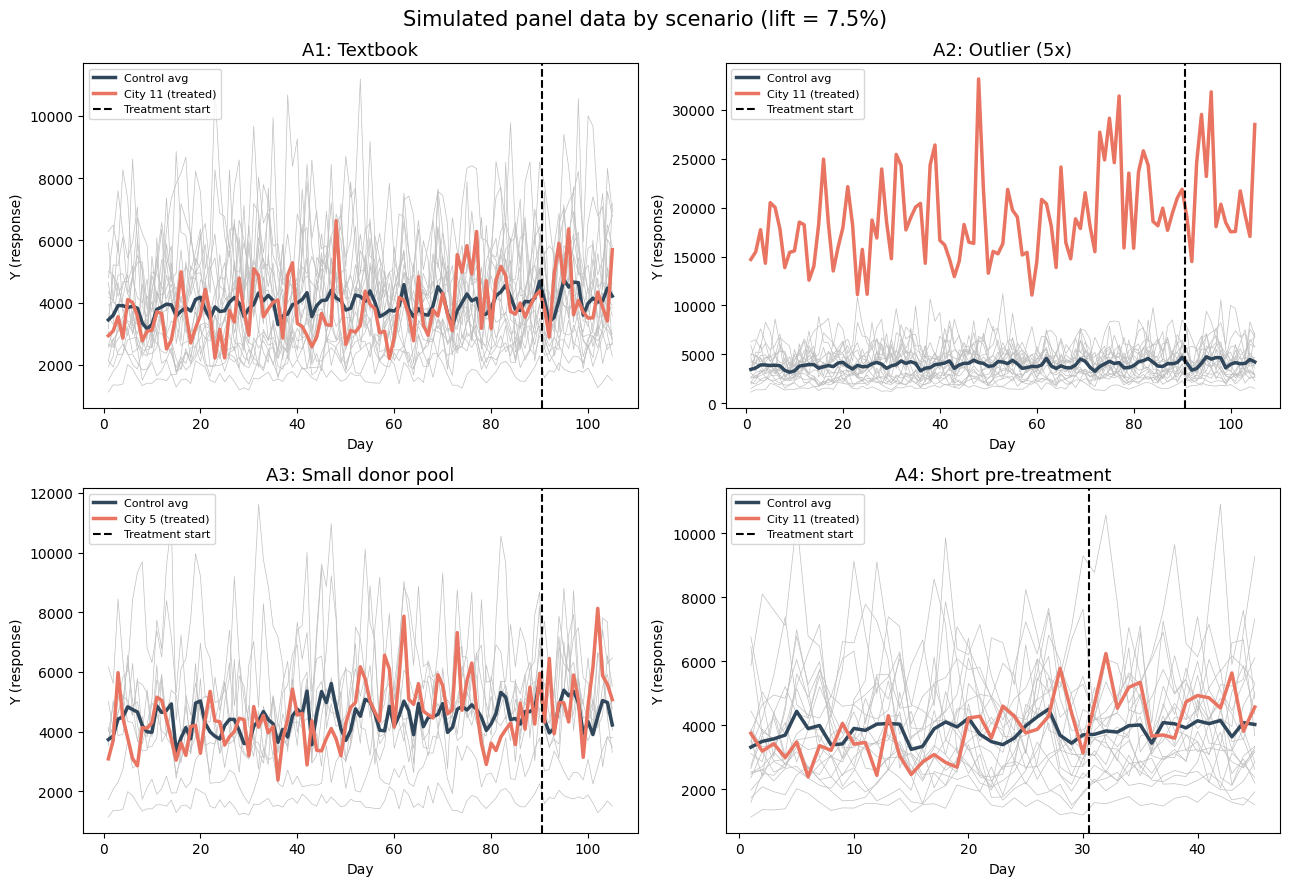

In [24]:
SCENARIO_LABELS = {
    "A1": "A1: Textbook",
    "A2": "A2: Outlier (5x)",
    "A3": "A3: Small donor pool",
    "A4": "A4: Short pre-treatment",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, scenario_id in zip(axes.flat, SCENARIOS):
    df, meta = panels[scenario_id]
    treated_geo = meta["treated_units"][0]
    control_geos = [g for g in df["geo"].unique() if g != treated_geo]

    for g in control_geos:
        gd = df[df["geo"] == g].sort_values("date")
        ax.plot(gd["date"], gd["Y"], color="#c0c0c0", linewidth=0.5)

    ctrl_avg = df[df["geo"].isin(control_geos)].groupby("date")["Y"].mean()
    ax.plot(ctrl_avg.index, ctrl_avg.values, color="#2f465b", linewidth=2.5, label="Control avg")

    td = df[df["geo"] == treated_geo].sort_values("date")
    ax.plot(td["date"], td["Y"], color="#E87461", linewidth=2.5, label=f"{treated_geo} (treated)")

    ax.axvline(meta["treatment_start"] - 0.5, color="black", linestyle="--", linewidth=1.5, label="Treatment start")
    ax.set_title(SCENARIO_LABELS[scenario_id], fontsize=13)
    ax.set_xlabel("Day")
    ax.set_ylabel("Y (response)")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle(f"Simulated panel data by scenario (lift = {EFFECT_PCT:.1%})", fontsize=15)
fig.tight_layout()
plt.show()


## 2. Run each tool on each scenario

- **GeoLift** and **CausalImpact** run as R subprocesses via their existing wrappers
  (`src/R/run_geolift.R`, `src/R/run_causalimpact.R`) — unchanged from the production
  pipeline.
- **Google Matched Markets** runs as a direct Python call (deterministic OLS-based TBR).

This can take ~10-30s per scenario (GeoLift's conformal inference and CausalImpact's
BSTS sampling are the slow parts).


In [25]:
def run_all_tools(df: pd.DataFrame, meta: dict) -> dict:
    treated_units = meta["treated_units"]
    treatment_start = meta["treatment_start"]
    treatment_end = meta["treatment_end"]

    geolift_df = to_geolift_format(df)
    mm_df = to_google_mm_format(df, treated_units, treatment_start)
    ci_df = df[["geo", "date", "Y"]].copy()

    gl_result = run_geolift_subprocess(
        geolift_df=geolift_df, treated_units=treated_units,
        treatment_start=treatment_start, treatment_end=treatment_end,
        alpha=GL_ALPHA,
    )
    ci_result = run_causalimpact_subprocess(
        ci_df=ci_df, treated_units=treated_units,
        treatment_start=treatment_start, treatment_end=treatment_end,
        ci_config=CI_CONFIG,
    )
    mm_result = run_google_mm(mm_df=mm_df, config=MM_CONFIG)

    return {"geolift": gl_result, "causalimpact": ci_result, "google_mm": mm_result}


tool_results = {}
for scenario_id in SCENARIOS:
    df, meta = panels[scenario_id]
    print(f"Running tools for {scenario_id}...")
    tool_results[scenario_id] = run_all_tools(df, meta)
print("Done.")


Running tools for A1...
Running tools for A2...
Running tools for A3...
Running tools for A4...
Done.


## 3. Compare each tool's estimate against the true ATT\n\nCoverage and CI width are compared on the **level scale** (not %), and ATT% uses the true DGP counterfactual as a shared denominator across tools — same fair-comparison protocol as `compute_att.py`.

In [26]:
def normalize_result(tool: str, result, true_att_level: float, true_cf_mean: float) -> dict:
    if tool == "google_mm":
        att_level = result.att_level
        ci_lower_level = result.ci_lower_level
        ci_upper_level = result.ci_upper_level
        significant = result.significant
        runtime = result.runtime_seconds
    else:  # geolift / causalimpact: dict from JSON
        att_level = result.get("att_level")
        ci_lower_level = result.get("ci_lower_level")
        ci_upper_level = result.get("ci_upper_level")
        significant = result.get("significant", False)
        runtime = result.get("runtime_seconds", 0)

    covered = (
        check_coverage(ci_lower_level, ci_upper_level, true_att_level)
        if att_level is not None else False
    )
    att_pct_unified = (
        att_level / true_cf_mean
        if att_level is not None and true_cf_mean != 0 else np.nan
    )
    return {
        "tool": tool,
        "att_level": att_level,
        "att_pct": att_pct_unified,
        "ci_lower_level": ci_lower_level,
        "ci_upper_level": ci_upper_level,
        "ci_width": (ci_upper_level - ci_lower_level)
            if ci_lower_level is not None and ci_upper_level is not None else np.nan,
        "covered": covered,
        "significant": significant,
        "runtime_seconds": runtime,
    }


comparison_tables = {}
for scenario_id in SCENARIOS:
    df, meta = panels[scenario_id]
    true_att_level, true_att_pct, true_cf_mean = compute_true_att(
        df, meta["treated_units"], meta["treatment_start"]
    )
    rows = [
        normalize_result(tool, result, true_att_level, true_cf_mean)
        for tool, result in tool_results[scenario_id].items()
    ]
    table = pd.DataFrame(rows)
    table["true_att_level"] = true_att_level
    table["true_att_pct"] = true_att_pct
    comparison_tables[scenario_id] = table

comparison_tables["A1"]


,tool,att_level,att_pct,ci_lower_level,ci_upper_level,ci_width,covered,significant,runtime_seconds,true_att_level,true_att_pct
0,geolift,387.745900,0.097347,-639.83840,624.880700,1264.719100,True,False,3.399000,298.735034,0.075
1,causalimpact,400.648300,0.100586,-26.44150,840.633500,867.075000,True,False,0.883000,298.735034,0.075
2,google_mm,295.541647,0.074198,-188.24444,779.327733,967.572173,True,False,0.053288,298.735034,0.075


## 4. Forest plot per scenario\n\nVertical line = true ATT (level scale). Horizontal bars = each tool's point estimate ± CI. A bar that doesn't cross the true-ATT line means that tool's CI failed to cover the truth for this draw.

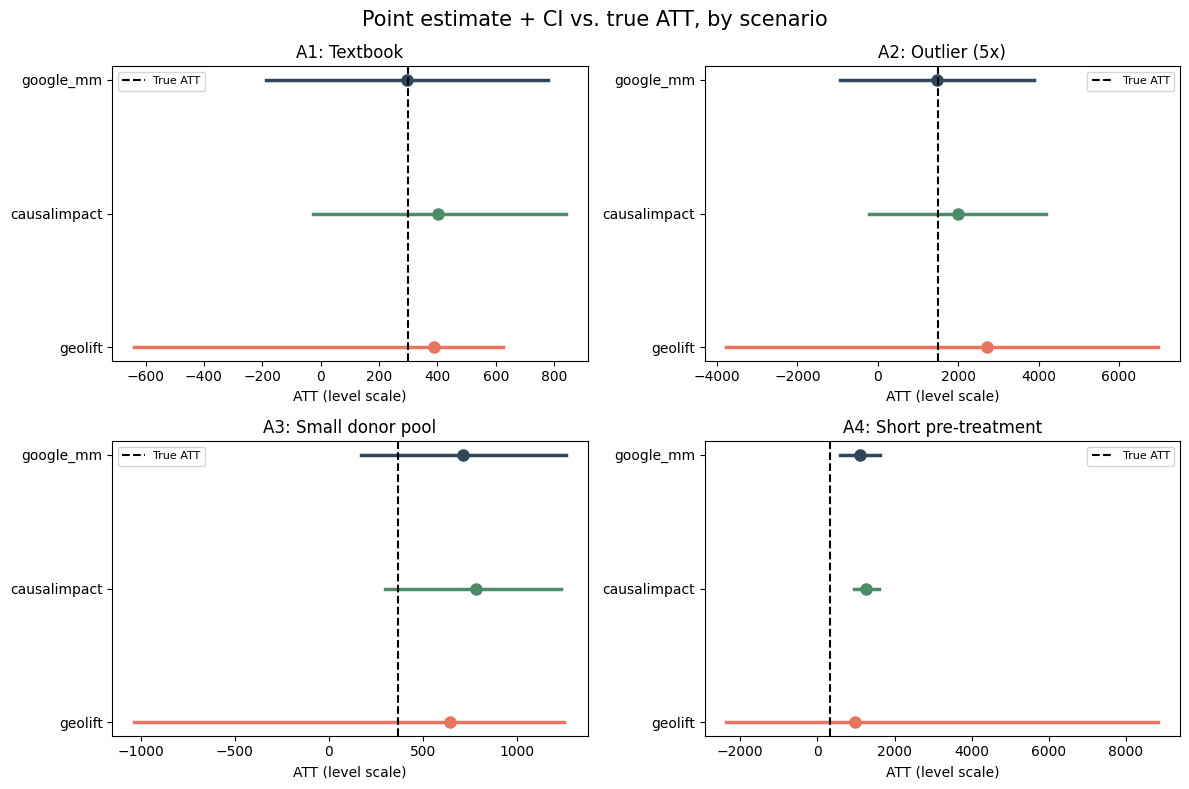

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, scenario_id in zip(axes.flat, SCENARIOS):
    table = comparison_tables[scenario_id]
    true_att_level = table["true_att_level"].iloc[0]

    y_pos = np.arange(len(table))
    for i, row in table.iterrows():
        color = TOOL_COLORS.get(row["tool"], "gray")
        if pd.notna(row["ci_lower_level"]) and pd.notna(row["ci_upper_level"]):
            ax.plot([row["ci_lower_level"], row["ci_upper_level"]], [i, i],
                     color=color, linewidth=2.5)
        if pd.notna(row["att_level"]):
            ax.plot(row["att_level"], i, "o", color=color, markersize=8)

    ax.axvline(true_att_level, color="black", linestyle="--", linewidth=1.5, label="True ATT")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(table["tool"])
    ax.set_title(SCENARIO_LABELS[scenario_id])
    ax.set_xlabel("ATT (level scale)")
    ax.legend(loc="best", fontsize=8)

fig.suptitle("Point estimate + CI vs. true ATT, by scenario", fontsize=15)
fig.tight_layout()
plt.show()


## 5. Cross-scenario summary table\n\nOne combined view across all 4 scenarios and 3 tools.

In [28]:
summary = pd.concat(
    [table.assign(scenario=scenario_id) for scenario_id, table in comparison_tables.items()],
    ignore_index=True,
)
summary = summary[[
    "scenario", "tool", "att_level", "true_att_level", "ci_width",
    "covered", "att_pct", "true_att_pct", "significant", "runtime_seconds",
]]
summary.sort_values(["scenario", "tool"]).reset_index(drop=True)


,scenario,tool,att_level,true_att_level,ci_width,covered,att_pct,true_att_pct,significant,runtime_seconds
0,A1,causalimpact,400.648300,298.735034,867.075000,True,0.100586,0.075,False,0.883000
1,A1,geolift,387.745900,298.735034,1264.719100,True,0.097347,0.075,False,3.399000
2,A1,google_mm,295.541647,298.735034,967.572173,True,0.074198,0.075,False,0.053288
3,A2,causalimpact,2003.241400,1493.675172,4398.710600,True,0.100586,0.075,False,0.887000
4,A2,geolift,2708.870600,1493.675172,10749.035300,True,0.136017,0.075,False,3.298000
5,A2,google_mm,1477.708234,1493.675172,4837.860865,True,0.074198,0.075,False,0.007411
6,A3,causalimpact,784.696700,366.408630,935.096100,True,0.160619,0.075,True,0.865000
7,A3,geolift,647.585000,366.408630,2287.872400,True,0.132554,0.075,False,2.952000
8,A3,google_mm,716.475166,366.408630,1090.835398,True,0.146655,0.075,True,0.007293
9,A4,causalimpact,1268.334900,325.694309,636.338100,False,0.292069,0.075,True,0.421000


In [29]:
summary.sort_values(["tool", "scenario"]).reset_index(drop=True)


,scenario,tool,att_level,true_att_level,ci_width,covered,att_pct,true_att_pct,significant,runtime_seconds
0,A1,causalimpact,400.648300,298.735034,867.075000,True,0.100586,0.075,False,0.883000
1,A2,causalimpact,2003.241400,1493.675172,4398.710600,True,0.100586,0.075,False,0.887000
2,A3,causalimpact,784.696700,366.408630,935.096100,True,0.160619,0.075,True,0.865000
3,A4,causalimpact,1268.334900,325.694309,636.338100,False,0.292069,0.075,True,0.421000
4,A1,geolift,387.745900,298.735034,1264.719100,True,0.097347,0.075,False,3.399000
5,A2,geolift,2708.870600,1493.675172,10749.035300,True,0.136017,0.075,False,3.298000
6,A3,geolift,647.585000,366.408630,2287.872400,True,0.132554,0.075,False,2.952000
7,A4,geolift,963.373200,325.694309,11199.011800,True,0.221843,0.075,False,1.111000
8,A1,google_mm,295.541647,298.735034,967.572173,True,0.074198,0.075,False,0.053288
9,A2,google_mm,1477.708234,1493.675172,4837.860865,True,0.074198,0.075,False,0.007411


## Discussion prompts

Use the plots and tables above to reason through:

1. **A1 (Textbook)** — Do all three tools land close to the true ATT? This is the
   baseline case; large disagreement here would be a red flag about the tools
   themselves rather than the scenario.
2. **A2 (Outlier)** — GeoLift's augmented synthetic control tries to match the treated
   geo's *level* using a weighted combination of donors. When the treated geo is 5x
   larger than every donor, no convex combination of donors can reach that level
   (a "convex hull violation"). Does GeoLift's CI widen to compensate, or does its
   point estimate become biased? How do CausalImpact (BSTS, no convex-combination
   constraint) and Google MM (simple OLS regression) compare here?
3. **A3 (Small donor pool)** — With only 9 control geos, is there enough donor
   flexibility for a good pre-period fit? Look at each tool's CI width relative to
   A1 — does less donor flexibility show up as wider intervals, biased point
   estimates, or both?
4. **A4 (Short pre-treatment)** — With only 30 pre-treatment days instead of 90,
   which tool's inference degrades the most? GeoLift's conformal inference and
   CausalImpact's BSTS model both need enough pre-period history to calibrate;
   Google MM's OLS regression needs enough points to estimate a stable relationship
   too.
5. Across all four scenarios, which tool's CI is most consistently well-calibrated
   (i.e., actually contains the true ATT), and which trades off calibration for a
   narrower/wider interval? Remember this is a **single draw per scenario** — for
   statistically robust answers to this question, see the full 1,000-iteration
   results in `results/aggregated/`.
